#Leer archivos



In [1]:
import pandas as pd
ruta = "/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/PUNTOS/Base de datos/MenM__Geohazards.csv"

puntos = pd.read_csv(ruta, encoding='latin1',
    sep=';',
    decimal=','
)
puntos.info()
puntos.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   type     511 non-null    object 
 1   date     511 non-null    object 
 2   lng      511 non-null    float64
 3   lat      511 non-null    float64
 4   Barrio   371 non-null    object 
dtypes: float64(2), object(3)
memory usage: 20.1+ KB


,type,date,lng,lat,Barrio
0,Landslide,31/12/2017,-75.606000,6.276000,NaN
1,Landslide,28/04/2018,-75.604805,6.243001,NaN
2,Landslide,21/05/2018,-75.604077,6.235881,NaN
3,Landslide,29/10/1975,-75.604077,6.235881,NaN
4,Landslide,14/07/1999,-75.603016,6.213929,NaN


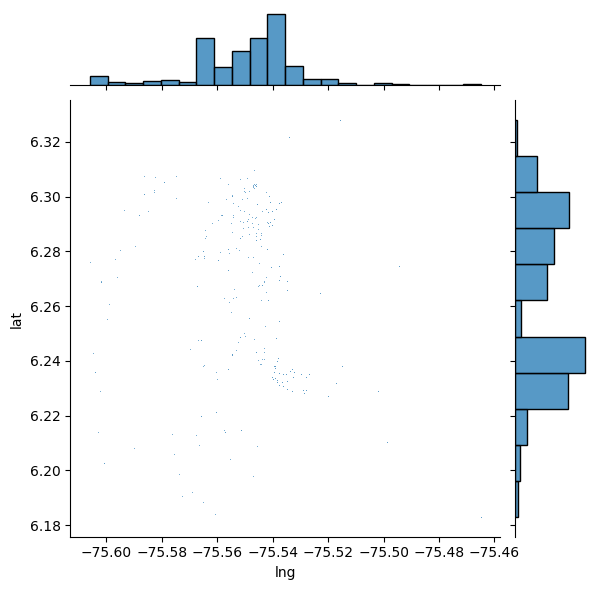

In [2]:
import seaborn as sbn
sbn.jointplot(x='lng', y='lat', data=puntos, s=0.5);

Index(['FID_', 'OBJECTID', 'COMUNA', 'SECTOR', 'NOMBRE', 'SHAPEAREA',
       'SHAPELEN', 'Shape__Are', 'Shape__Len', 'geometry'],
      dtype='object')

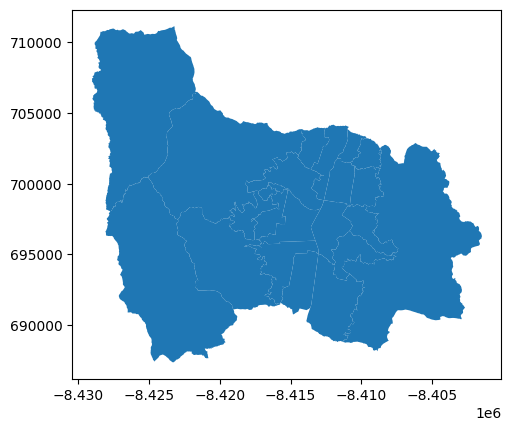

In [3]:
import geopandas as gpd
comuna = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/comunas_med")
comuna.plot();
comuna.head()
comuna.crs
comuna.columns

<Axes: >

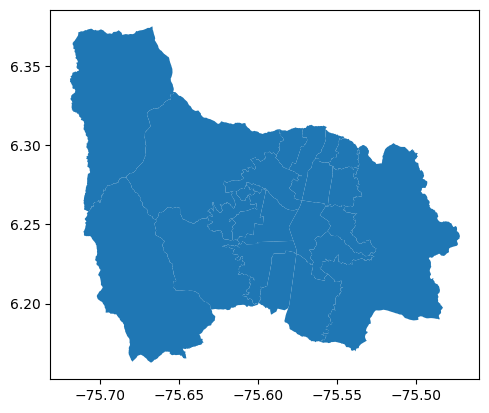

In [4]:
comuna = comuna.to_crs("EPSG:4326")
comuna.plot()

<Axes: xlabel='lng', ylabel='lat'>

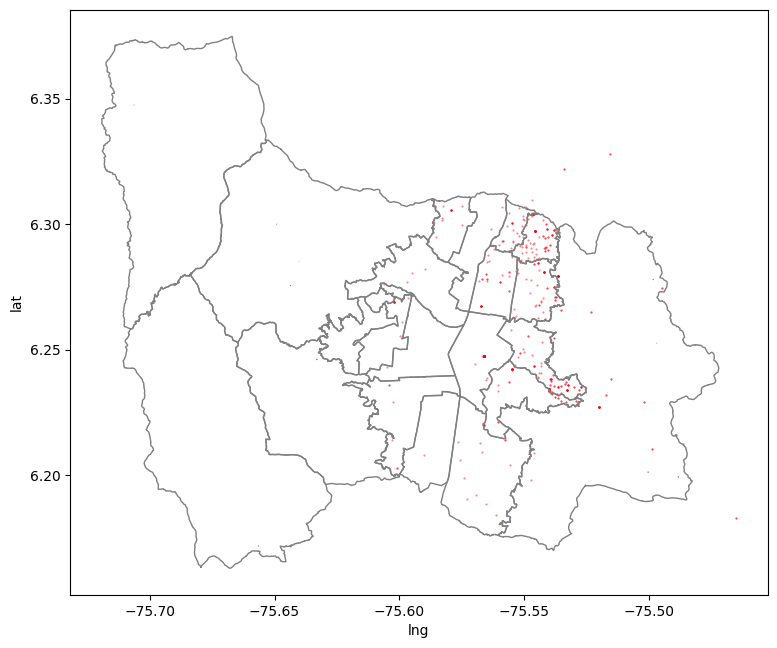

In [5]:
# Plot photographs with smaller, more translucent dots
ax = puntos.plot.scatter("lng","lat",s=0.25,c="xkcd:bright red",alpha=0.5,figsize=(9, 9))
comuna.plot(ax=ax,facecolor="none",edgecolor="gray")
# remove axis


<Axes: >

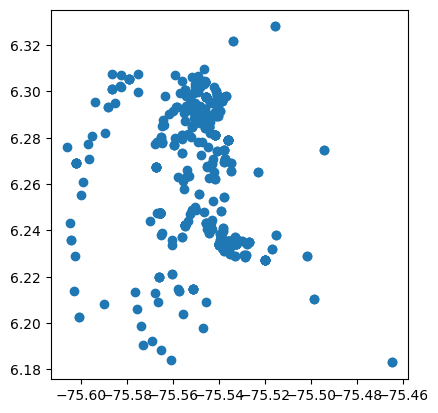

In [6]:
import geopandas as gpd

mem = gpd.GeoDataFrame(
    puntos,
    geometry=gpd.points_from_xy(puntos.lng, puntos.lat),
    crs="EPSG:4326"
)

mem.plot()


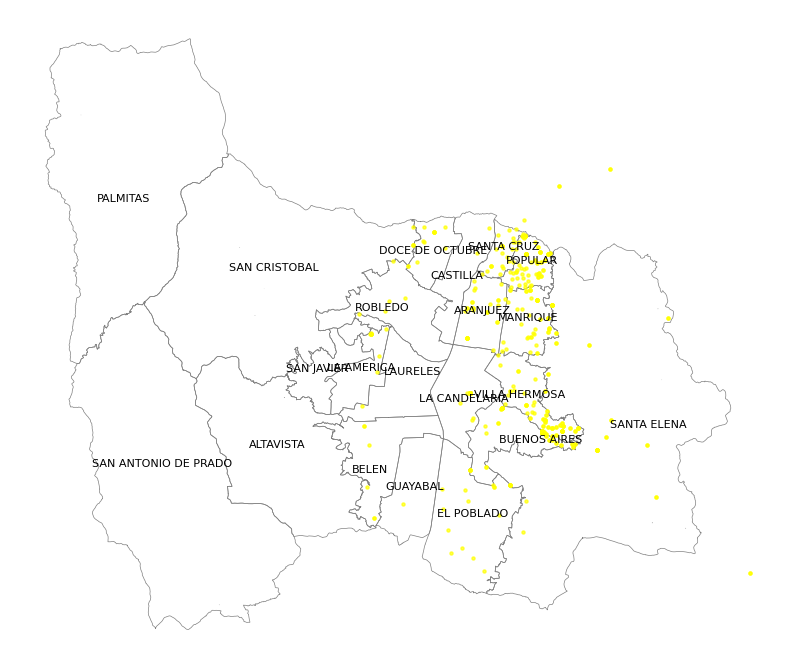

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,10))

# Áreas
comuna.plot(ax=ax, facecolor="none", edgecolor="gray",linewidth=0.5)

# puntos
mem.plot(ax=ax, color="yellow", markersize=5,alpha=0.7)


comuna["coords"] = comuna.geometry.representative_point()

for idx, row in comuna.iterrows():
    ax.text(
        row["coords"].x,
        row["coords"].y,
        row["NOMBRE"],  # o el campo que tenga el nombre de la comuna
        fontsize=8,
        ha='center')

ax.set_axis_off()
plt.show()